In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import norm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.models.xgboost_model import *
from src.models.ngboost_model import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/processed/training/PTS_TRAIN_23.csv')
s24 = pd.read_csv('data/processed/training/PTS_TRAIN_24.csv')
s25 = pd.read_csv('data/processed/training/PTS_TRAIN_25.csv')
s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv')

for df in [s23,s24,s25,s26]:
    df['FOULS_L5_PER_MIN'] = df['PF_ROLLING_AVG_5'] / df['MIN_ROLLING_AVG_5']

train_df = pd.concat([s23,s24,s25])
val_df = s26

print("BEFORE FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
train_df.sample()


C:\Users\alexg\AppData\Local\Temp\ipykernel_3952\404023875.py:6: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv')


BEFORE FILTERING:
Train set: 78629 samples
Val set: 21261 samples


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,UFGM_ROLLING_AVG_5,CFGA_ROLLING_AVG_5,CFGM_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,POSS_ROLLING_AVG_5,PLUS_MINUS_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,SPD_ROLLING_AVG_5,PF_ROLLING_AVG_5,PASS_ROLLING_AVG_5,SAST_ROLLING_AVG_5,AST_ROLLING_AVG_5,REB_ROLLING_AVG_5,OREB_ROLLING_AVG_5,DREB_ROLLING_AVG_5,TOV_ROLLING_AVG_5,PACE_ROLLING_AVG_5,E_DEF_RATING_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,PTS_OFF_TOV_ROLLING_AVG_5,PTS_2ND_CHANCE_ROLLING_AVG_5,PTS_FB_ROLLING_AVG_5,PTS_PAINT_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,UFGM_ROLLING_AVG_7,CFGA_ROLLING_AVG_7,CFGM_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,POSS_ROLLING_AVG_7,PLUS_MINUS_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,SPD_ROLLING_AVG_7,PF_ROLLING_AVG_7,PASS_ROLLING_AVG_7,SAST_ROLLING_AVG_7,AST_ROLLING_AVG_7,REB_ROLLING_AVG_7,OREB_ROLLING_AVG_7,DREB_ROLLING_AVG_7,TOV_ROLLING_AVG_7,PACE_ROLLING_AVG_7,E_DEF_RATING_ROLLING_AVG_7,PIE_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,FG3_PCT_ROLLING_AVG_7,FT_PCT_ROLLING_AVG_7,PTS_OFF_TOV_ROLLING_AVG_7,PTS_2ND_CHANCE_ROLLING_AVG_7,PTS_FB_ROLLING_AVG_7,PTS_PAINT_ROLLING_AVG_7,PTS_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,UFGA_ROLLING_AVG_

In [7]:
# ============================================================================
# PLAYER-LEVEL FILTERING
# ============================================================================
player_season_avg = train_df.groupby('PLAYER_ID').agg({
    'MIN': 'mean',
    'PTS': 'mean',
    'FGA': 'mean',
    'GAMES_PLAYED_TO_DATE': 'max'
}).reset_index()

player_season_avg.columns = ['PLAYER_ID', 'MIN_AVG', 'PTS_AVG', 'FGA_AVG', 'GAMES_PLAYED']

# Define relevant players (meaningful rotation players)
relevant_players = player_season_avg[
    (player_season_avg['MIN_AVG'] >= 25) &      # At least 10 min/game avg
    (player_season_avg['GAMES_PLAYED'] >= 5) &  # At least 5 games played
    (player_season_avg['FGA_AVG'] >= 2)         # At least 2 shot attempts/game
]['PLAYER_ID']

print(f"Relevant players identified: {len(relevant_players)}")

# ============================================================================
# GAME-LEVEL FILTERING (Applied to both train and val)
# ============================================================================
def filter_game_data(df, relevant_players):
    """
    Filter out outlier games and ensure data quality
    """
    df_filtered = df.copy()
    
    # Filter to relevant players only
    df_filtered = df_filtered[df_filtered['PLAYER_ID'].isin(relevant_players)]
    
    # Remove extreme outliers and data quality issues
    df_filtered = df_filtered[
        # Minutes played constraints (DNPs and full games)
        (df_filtered['MIN'] >= 5) &           # Played meaningful minutes
        (df_filtered['MIN'] <= 48) &          # No overtime anomalies
        
        # Points constraints
        (df_filtered['PTS'] <= 60) &          # Remove historic outliers
        
        # Shot attempts constraints (remove statistical errors)
        (df_filtered['FGA'] <= 35) &          # Unrealistic FGA
        (df_filtered['FGA'] >= 0) &           # No negative values
        (df_filtered['FG3A'] <= df_filtered['FGA']) &  # 3PA can't exceed FGA
        (df_filtered['FTA'] <= 25) &          # Unrealistic FTA
        (df_filtered['FTA'] >= 0) &           # No negative values
        
        # Usage constraints (remove extreme outliers)
        (df_filtered['USG_PCT'] <= 0.45) &    # Max realistic usage
        (df_filtered['USG_PCT'] >= 0.05)      # Min realistic usage for rotation players
    ]
    
    return df_filtered

# Apply filtering
train_df_filtered = filter_game_data(train_df, relevant_players)
val_df_filtered = filter_game_data(val_df, relevant_players)

# ============================================================================
# VALIDATION AND SUMMARY
# ============================================================================
print("\n" + "="*60)
print("FILTERING RESULTS")
print("="*60)

print(f"\nOriginal sizes:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val:   {len(val_df):,} samples")

print(f"\nFiltered sizes:")
print(f"  Train: {len(train_df_filtered):,} samples ({len(train_df_filtered)/len(train_df)*100:.1f}% retained)")
print(f"  Val:   {len(val_df_filtered):,} samples ({len(val_df_filtered)/len(val_df)*100:.1f}% retained)")

print(f"\nUnique players:")
print(f"  Train: {train_df_filtered['PLAYER_ID'].nunique()}")
print(f"  Val:   {val_df_filtered['PLAYER_ID'].nunique()}")

# Update your dataframes
train_df = train_df_filtered
val_df = val_df_filtered

print("\n✓ Filtering complete!")

Relevant players identified: 190

FILTERING RESULTS

Original sizes:
  Train: 78,629 samples
  Val:   21,261 samples

Filtered sizes:
  Train: 33,564 samples (42.7% retained)
  Val:   7,987 samples (37.6% retained)

Unique players:
  Train: 190
  Val:   176

✓ Filtering complete!


In [ ]:
min_features = [
    'PLAYER_IS_TEAM_STAR', #new
    'STARTING_X_MIN',
    'USUAL_STARTERS_AVAILABLE',
    'MIN_LAG_1',
    'MIN_LAG_2',
    'MIN_LAG_3',
    'MIN_ROLLING_AVG_7',
    'MIN_TEAM_RANK',
    'PTS_TEAM_RANK',
    'PLAYER_DAYS_REST',
    'STARTER_X_DAYS_REST',
    'PLAYER_MISSED_LAST_GAME_X_MIN',
    'MIN_BOOST_STAR_OUT',
    'MIN_STD_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    'PACE_AVG_TO_DATE',
    'GAMES_PLAYED_TO_DATE',
    'FOULS_L5_PER_MIN',
    'PF_AVG_TO_DATE',
    'PLUS_MINUS_AVG_TO_DATE'
]


min_features = remove_highly_correlated_features(val_df, min_features, target_col='MIN', threshold=0.95)
print(f"len(MIN_features): {len(min_features)}")
min_features

Features to remove: set()
Removed 0 highly correlated features. Final: 7
len(MIN_features): 7


['MIN_ROLLING_AVG_7',
 'PLAYER_DAYS_REST',
 'PACE_AVG_TO_DATE',
 'GAMES_PLAYED_TO_DATE',
 'FOULS_L5_PER_MIN',
 'PF_AVG_TO_DATE',
 'PLUS_MINUS_AVG_TO_DATE']

: 

In [6]:
fga_features = [
    'FGA_ROLLING_AVG_10',  # 1.34
    'USG_PCT_AVG_TO_DATE',  # 0.63
    'FGA_TEAM_RANK',  # 0.62
    'STARTING_X_FGA',  # 0.56
    'POSS_AVG_TO_DATE',  # 0.53
    'STARTING_X_MIN',  # 0.45
    'LINEUP_FGA_SHARE_AVG',  # 0.22
    'FGA_BOOST_STAR_OUT',  # 0.19
    'UFGA_AVG_TO_DATE',  # 0.18
    'MIN_L5_OVER_BASELINE',  # 0.16 - Keep for FGA model (minute trend signal)
    'USG_PCT_BOOST_STAR_OUT',  # 0.12
    
    # Medium-value features (SHAP 0.08-0.15)
    'TEAM_PACE_L3_OVER_LEAGUE_AVG',  # 0.11
    'FG3A_TEAM_RANK',  # 0.11
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',  # 0.10
    'FGA_LAG_1',  # 0.10
    'E_OFF_RATING_AVG_TO_DATE',  # 0.10
    'TCHS_AVG_TO_DATE',  # 0.10
    'TEAM_FGA_AVG_TO_DATE',  # 0.09
    'PACE_DIFFERENTIAL',  # 0.09
    'EXPECTED_PACE',  # 0.09
    'FGA_L3_OVER_BASELINE',  # 0.09
    'CENTER_DEF_RATING_OVER_LEAGUE_AVG',  # 0.08
    
    # Contextual features worth keeping (SHAP 0.06-0.08)
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_OFF_RATING_L3_OVER_LEAGUE_AVG',  # 0.08
    'FG3A_AVG_TO_DATE',  # 0.07
    'CFGA_AVG_TO_DATE',  # 0.06
    'AST_AVG_TO_DATE',  # 0.06
    'TOV_AVG_TO_DATE',  # 0.06
    'FTA_AVG_TO_DATE',  # 0.06
]
fga_features = remove_highly_correlated_features(val_df, fga_features, target_col='FGA', threshold=0.95)
fga_features

Features to remove: set()
Removed 0 highly correlated features. Final: 29


['FGA_ROLLING_AVG_10',
 'USG_PCT_AVG_TO_DATE',
 'FGA_TEAM_RANK',
 'STARTING_X_FGA',
 'POSS_AVG_TO_DATE',
 'STARTING_X_MIN',
 'LINEUP_FGA_SHARE_AVG',
 'FGA_BOOST_STAR_OUT',
 'UFGA_AVG_TO_DATE',
 'MIN_L5_OVER_BASELINE',
 'USG_PCT_BOOST_STAR_OUT',
 'TEAM_PACE_L3_OVER_LEAGUE_AVG',
 'FG3A_TEAM_RANK',
 'OPP_DEF_RATING_OVER_LEAGUE_AVG',
 'FGA_LAG_1',
 'E_OFF_RATING_AVG_TO_DATE',
 'TCHS_AVG_TO_DATE',
 'TEAM_FGA_AVG_TO_DATE',
 'PACE_DIFFERENTIAL',
 'EXPECTED_PACE',
 'FGA_L3_OVER_BASELINE',
 'CENTER_DEF_RATING_OVER_LEAGUE_AVG',
 'TEAM_OFF_RATING_AVG_TO_DATE',
 'TEAM_OFF_RATING_L3_OVER_LEAGUE_AVG',
 'FG3A_AVG_TO_DATE',
 'CFGA_AVG_TO_DATE',
 'AST_AVG_TO_DATE',
 'TOV_AVG_TO_DATE',
 'FTA_AVG_TO_DATE']

In [7]:
fg3a_features = [
    # Core predictors - CRITICAL (SHAP > 0.30)
    'FG3A_ROLLING_AVG_10',  # 0.66
    'FG3A_PCT_OF_FGA',  # 0.65 - Shot selection style
    'TEAM_FG3A_ROLLING_AVG_5',  # 0.31
    
    # High-value features (SHAP 0.10-0.30)
    'USG_PCT_ROLLING_AVG_5',  # 0.23
    'FG3A_DELTA_TOPFG3A_RANK_OUT',  # 0.21 - Injury replacement
    'FGA_ROLLING_AVG_5',  # 0.16
    'FG3M_AVG_TO_DATE',  # 0.14 - Made 3s (confidence indicator)
    'TEAM_FG3A_AVG_TO_DATE',  # 0.13
    
    # Medium-value features (SHAP 0.04-0.10)
    'FG3A_TEAM_RANK',
    'FG3A_PER_MIN',
    'FG3A_DELTA_STAR_OUT',  # 0.08
    'FG_PCT_AVG_TO_DATE',  # 0.06
    'TEAM_PACE_L5_OVER_LEAGUE_AVG',  # 0.06
    'CENTER_DEF_RATING_OVER_LEAGUE_AVG',  # 0.06
    'DIST_AVG_TO_DATE',  # 0.06 - Shot distance
    'FGA_L5_OVER_BASELINE',  # 0.05
    # 'MIN_ROLLING_AVG_5',  # 0.05
    'STAR_SAT_OUT',  # 0.05
    'FG3A_BOOST_STAR_OUT',  # 0.05
    'FG3M_ROLLING_AVG_5',  # 0.05
    'TCHS_AVG_TO_DATE',  # 0.04
    'USG_PCT_L5_OVER_BASELINE',  # 0.04
    'FGA_DELTA_TOPFGA_RANK_OUT',  # 0.04
    
    # Marginal features worth keeping (SHAP 0.03-0.04)
    'FG3_PCT_AVG_TO_DATE',  # 0.03
    'FG3A_STD_10_TO_DATE',  # 0.03 - Variability
    'FG3A_LAG_1',  # 0.03
    'STARTING_X_FG3A',  # 0.03
    'E_OFF_RATING_AVG_TO_DATE',  # 0.03
    'EXPECTED_PACE',  # 0.03
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',  # 0.03
    'MATCHUP_AVG_FG3_PCT_TO_DATE',  # 0.03
]

# Calculate derived features before training:
# FG3A_PER_MIN = FG3A_AVG_TO_DATE / (PREDICTED_MIN + 1e-8)
fg3a_features = remove_highly_correlated_features(val_df, fg3a_features, target_col='FG3A', threshold=0.95)
print(f"len(fg3a_features): {len(fg3a_features)}")
fg3a_features

Features to remove: set()
Removed 0 highly correlated features. Final: 29
len(fg3a_features): 29


['FG3A_ROLLING_AVG_10',
 'FG3A_PCT_OF_FGA',
 'TEAM_FG3A_ROLLING_AVG_5',
 'USG_PCT_ROLLING_AVG_5',
 'FG3A_DELTA_TOPFG3A_RANK_OUT',
 'FGA_ROLLING_AVG_5',
 'FG3M_AVG_TO_DATE',
 'TEAM_FG3A_AVG_TO_DATE',
 'FG3A_TEAM_RANK',
 'FG3A_DELTA_STAR_OUT',
 'FG_PCT_AVG_TO_DATE',
 'TEAM_PACE_L5_OVER_LEAGUE_AVG',
 'CENTER_DEF_RATING_OVER_LEAGUE_AVG',
 'DIST_AVG_TO_DATE',
 'FGA_L5_OVER_BASELINE',
 'STAR_SAT_OUT',
 'FG3A_BOOST_STAR_OUT',
 'FG3M_ROLLING_AVG_5',
 'TCHS_AVG_TO_DATE',
 'USG_PCT_L5_OVER_BASELINE',
 'FGA_DELTA_TOPFGA_RANK_OUT',
 'FG3_PCT_AVG_TO_DATE',
 'FG3A_STD_10_TO_DATE',
 'FG3A_LAG_1',
 'STARTING_X_FG3A',
 'E_OFF_RATING_AVG_TO_DATE',
 'EXPECTED_PACE',
 'OPP_DEF_RATING_OVER_LEAGUE_AVG',
 'MATCHUP_AVG_FG3_PCT_TO_DATE']

In [8]:
fta_features = [
    # Core predictors - CRITICAL (SHAP > 0.30)
    'TEAM_FTA_ROLLING_AVG_5',  # 0.53 - Team free throw tendency
    'FTA_TEAM_RANK',  # 0.36 - Player's FT role hierarchy
    'FTA_ROLLING_AVG_10',  # 0.34
    
    # High-value features (SHAP 0.10-0.30)
    'FTA_DELTA_TOPFTA_RANK_OUT',  # 0.25 - Injury replacement
    'FTA_BOOST_STAR_OUT',  # 0.20
    'FTA_PER_FGA',  # 0.15 - Free throw rate (style)
    'FTA_DELTA_STAR_OUT',  # 0.14
    'FTA_PER_MIN',
    
    # Medium-value features (SHAP 0.05-0.10)
    'TEAM_FTA_AVG_TO_DATE',  # 0.08
    'PLAYER_HOME_AVG_FTA_TO_DATE',  # 0.07 - Home splits matter for FTA
    'POSS_AVG_TO_DATE',  # 0.07
    'FGA_DELTA_TOPFGA_RANK_OUT',  # 0.06
    'FG_PCT_AVG_TO_DATE',  # 0.06
    'CENTER_DEF_RATING_OVER_LEAGUE_AVG',  # 0.06
    'STARTING',  # 0.06
    'LINEUP_FGA_SHARE_AVG',  # 0.06
    'PTS_AVG_TO_DATE',  # 0.06
    
    # Lower-value features worth keeping (SHAP 0.04-0.05)
    'PF_AVG_TO_DATE',  # 0.05 - Fouls drawn
    'FTA_LAG_1',  # 0.05
    'FTA_EXPECTATION_LOCATION',  # 0.05 - Referee/venue effects
    'FTA_STD_10_TO_DATE',  # 0.05
    'FTA_L3_OVER_BASELINE',  # 0.04 - Recent trend (keep this one)
    'PLAYER_AWAY_FTA_DELTA',  # 0.04
    'PLAYER_AWAY_AVG_FTA_TO_DATE',  # 0.04
    'PACE_DIFFERENTIAL',  # 0.04
    'EXPECTED_PACE',  # 0.04
    'TCHS_AVG_TO_DATE',  # 0.04
    'E_OFF_RATING_AVG_TO_DATE',  # 0.04
    'NET_RATING_AVG_TO_DATE',  # 0.04
    'AST_AVG_TO_DATE',  # 0.04
    'PACE_ROLLING_AVG_5',  # 0.04
    
    # Marginal features (SHAP 0.03)
    'USG_PCT_VARIANCE_STABILITY',  # 0.04
    'USG_PCT_AVG_TO_DATE',  # 0.04
    'FTA_STD_5_TO_DATE',  # 0.03
    'TOV_AVG_TO_DATE',  # 0.03
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',  # 0.03
    'PLAYER_HOME_FTA_DELTA',  # 0.03
    'FTA_LAG_2',  # 0.03
    'GUARD',  # 0.03
]

fta_features = remove_highly_correlated_features(val_df, fta_features, target_col='FTA', threshold=0.95)
print(f"len(fta_features): {len(fta_features)}")
fta_features

Features to remove: set()
Removed 0 highly correlated features. Final: 38
len(fta_features): 38


['TEAM_FTA_ROLLING_AVG_5',
 'FTA_TEAM_RANK',
 'FTA_ROLLING_AVG_10',
 'FTA_DELTA_TOPFTA_RANK_OUT',
 'FTA_BOOST_STAR_OUT',
 'FTA_PER_FGA',
 'FTA_DELTA_STAR_OUT',
 'TEAM_FTA_AVG_TO_DATE',
 'PLAYER_HOME_AVG_FTA_TO_DATE',
 'POSS_AVG_TO_DATE',
 'FGA_DELTA_TOPFGA_RANK_OUT',
 'FG_PCT_AVG_TO_DATE',
 'CENTER_DEF_RATING_OVER_LEAGUE_AVG',
 'STARTING',
 'LINEUP_FGA_SHARE_AVG',
 'PTS_AVG_TO_DATE',
 'PF_AVG_TO_DATE',
 'FTA_LAG_1',
 'FTA_EXPECTATION_LOCATION',
 'FTA_STD_10_TO_DATE',
 'FTA_L3_OVER_BASELINE',
 'PLAYER_AWAY_FTA_DELTA',
 'PLAYER_AWAY_AVG_FTA_TO_DATE',
 'PACE_DIFFERENTIAL',
 'EXPECTED_PACE',
 'TCHS_AVG_TO_DATE',
 'E_OFF_RATING_AVG_TO_DATE',
 'NET_RATING_AVG_TO_DATE',
 'AST_AVG_TO_DATE',
 'PACE_ROLLING_AVG_5',
 'USG_PCT_VARIANCE_STABILITY',
 'USG_PCT_AVG_TO_DATE',
 'FTA_STD_5_TO_DATE',
 'TOV_AVG_TO_DATE',
 'OPP_DEF_RATING_OVER_LEAGUE_AVG',
 'PLAYER_HOME_FTA_DELTA',
 'FTA_LAG_2',
 'GUARD']

In [9]:
# Train cascading model: MIN -> FGA -> FG3A -> FTA -> PTS
cascading_models = train_cascading_model(
    train_data=train_df,
    val_data=val_df,
    min_features=min_features,
    fga_features=fga_features,
    fg3a_features=fg3a_features,
    fta_features=fta_features,
    date_column='GAME_DATE',
    player_column='PLAYER_ID'
)

# Extract models and metrics
min_model = cascading_models['min_model']
fga_model = cascading_models['fga_model']
fg3a_model = cascading_models['fg3a_model']
fta_model = cascading_models['fta_model']
metrics = cascading_models['metrics']


Training XGBoost Model
Validation - RMSE: 5.380, MAE: 4.157, R²: 0.620
Training XGBoost Model
Validation - RMSE: 3.387, MAE: 2.603, R²: 0.642
Training XGBoost Model
Validation - RMSE: 1.750, MAE: 1.312, R²: 0.671
Training XGBoost Model
Validation - RMSE: 2.301, MAE: 1.731, R²: 0.458

MIN Model - RMSE: 5.380, MAE: 4.157, R²: 0.620
FGA Model - RMSE: 3.387, MAE: 2.603, R²: 0.642
FG3A Model - RMSE: 1.750, MAE: 1.312, R²: 0.671
FTA Model - RMSE: 2.301, MAE: 1.731, R²: 0.458


In [11]:
def add_predictions(df, min_model, fga_model, fg3a_model, fta_model, min_features, fga_features, fg3a_features, fta_features):
    """Add predicted MIN, FGA, FG3A, and FTA to dataframe using trained cascading models"""
    df = df.copy()
    
    # Predict MIN first
    X_min = df[min_features].fillna(0)
    df['PREDICTED_MIN'] = min_model.predict(X_min)
    
    # Calculate interaction features for FGA model
    df['EXPECTED_PACE_x_PREDICTED_MIN'] = (
        df['EXPECTED_PACE'] * df['PREDICTED_MIN']
    )
    df['FGA_PER_MIN'] = (
        df['FGA_ROLLING_AVG_10'] / (df['PREDICTED_MIN'] + 1e-8)
    ).round(3)
    df['FGA_PER_MIN'] = df['FGA_PER_MIN'].fillna(0.0)

    # Predict FGA using predicted MIN
    X_fga = df[fga_features].copy()
    X_fga['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_fga['FGA_PER_MIN'] = df['FGA_PER_MIN']
    X_fga = X_fga.fillna(0)
    df['PREDICTED_FGA'] = fga_model.predict(X_fga)
    
    # Calculate interaction features for FG3A model
    df['EXPECTED_PACE_x_PREDICTED_FGA'] = (
        df['EXPECTED_PACE'] * df['PREDICTED_FGA']
    )
    # Calculate FG3A_PER_MIN using predicted FGA (matches training code)
    df['FG3A_PER_MIN'] = (
        df['FG3A_ROLLING_AVG_10'] / (df['PREDICTED_FGA'] + 1e-8)
    ).round(3)
    df['FG3A_PER_MIN'] = df['FG3A_PER_MIN'].fillna(0.0)
    
    # Predict FG3A using predicted MIN and predicted FGA
    X_fg3a = df[fg3a_features].copy()
    X_fg3a['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_fg3a['PREDICTED_FGA'] = df['PREDICTED_FGA']
    X_fg3a['FG3A_PER_MIN'] = df['FG3A_PER_MIN']  # ← ADD THIS
    X_fg3a = X_fg3a.fillna(0)
    df['PREDICTED_FG3A'] = fg3a_model.predict(X_fg3a)
    
    # Calculate interaction features for FTA model
    df['EXPECTED_PACE_x_PREDICTED_FGA_x_PREDICTED_FG3A'] = (
        df['EXPECTED_PACE'] * df['PREDICTED_FGA'] * df['PREDICTED_FG3A']
    )
    # Calculate FTA_PER_MIN using predicted FGA and FG3A (matches training code)
    df['FTA_PER_MIN'] = (
        df['FTA_ROLLING_AVG_10'] / (df['PREDICTED_FGA'] * df['PREDICTED_FG3A'] + 1e-8)
    ).round(3)
    df['FTA_PER_MIN'] = df['FTA_PER_MIN'].fillna(0.0)
    
    # Predict FTA using predicted MIN, predicted FGA, and predicted FG3A
    X_fta = df[fta_features].copy()
    X_fta['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_fta['PREDICTED_FGA'] = df['PREDICTED_FGA']
    X_fta['PREDICTED_FG3A'] = df['PREDICTED_FG3A']
    X_fta['FTA_PER_MIN'] = df['FTA_PER_MIN']  # ← ADD THIS
    X_fta = X_fta.fillna(0)
    df['PREDICTED_FTA'] = fta_model.predict(X_fta)
    
    return df

train_df_with_preds = add_predictions(train_df, min_model, fga_model, fg3a_model, fta_model, min_features, fga_features, fg3a_features, fta_features)
val_df_with_preds = add_predictions(val_df, min_model, fga_model, fg3a_model, fta_model, min_features, fga_features, fg3a_features, fta_features)

Top 25 Features by SHAP importance:
  STARTER_X_DAYS_REST            2.4125
  STARTING_X_MIN                 1.3586
  MIN_ROLLING_AVG_7              1.2754
  MIN_TEAM_RANK                  1.0561
  MIN_LAG_1                      0.7226
  PTS_TEAM_RANK                  0.4722
  MIN_BOOST_STAR_OUT             0.3185
  MIN_LAG_2                      0.2517
  PF_AVG_TO_DATE                 0.2458
  MIN_LAG_3                      0.1456
  EXPECTED_PACE                  0.1267
  PLAYER_MISSED_LAST_GAME_X_MIN  0.1264
  USUAL_STARTERS_AVAILABLE       0.1108
  PACE_AVG_TO_DATE               0.1075
  PLAYER_DAYS_REST               0.1074
  PLUS_MINUS_AVG_TO_DATE         0.0961
  MIN_STD_5_TO_DATE              0.0939
  GAMES_PLAYED_TO_DATE           0.0932
  MIN_VOLATILITY_10_TO_DATE      0.0877
  FOULS_L5_PER_MIN               0.0875
  TEAM_PACE_OVER_LEAGUE_AVG      0.0657
  PLAYER_IS_TEAM_STAR            0.0396
Bottom 25 Features by SHAP importance:
  STARTER_X_DAYS_REST            2.4125
  STA

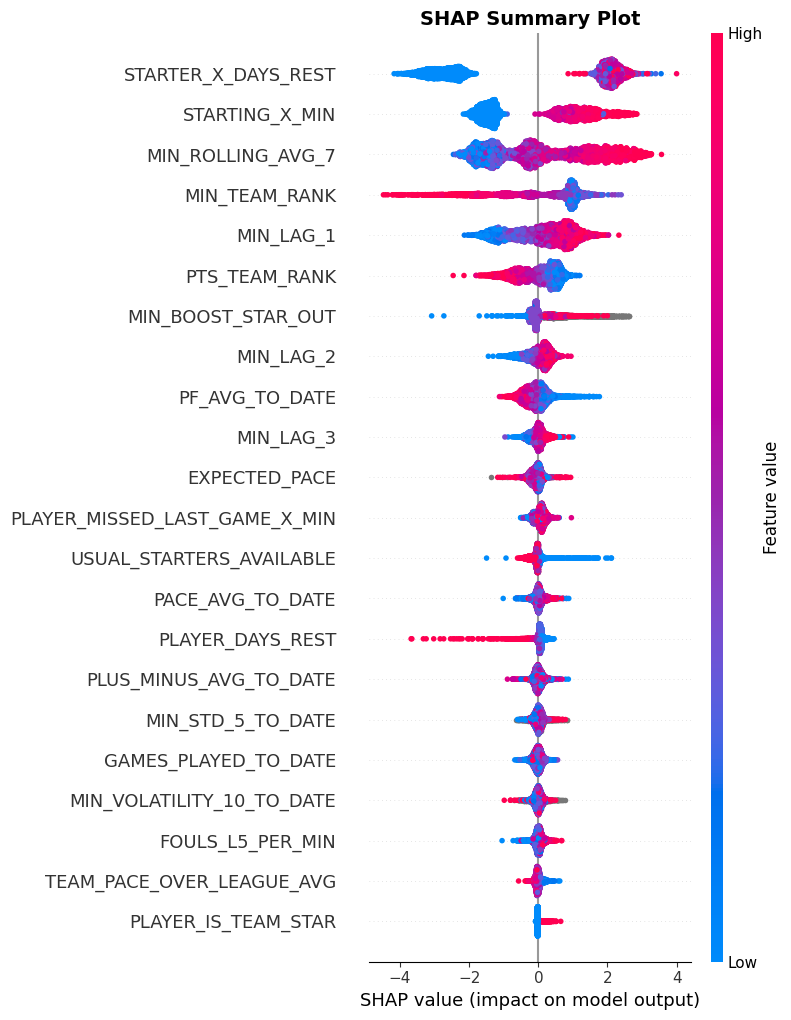

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
analyze_shap(min_model, val_df_with_preds, min_features, 'MIN')

Top 25 Features by SHAP importance:
  PREDICTED_MIN                  1.9688
  FGA_ROLLING_AVG_10             1.5232
  USG_PCT_AVG_TO_DATE            0.6492
  STARTING_X_FGA                 0.5913
  STARTING_X_MIN                 0.3874
  POSS_AVG_TO_DATE               0.3660
  FGA_TEAM_RANK                  0.2419
  FGA_PER_MIN                    0.2341
  LINEUP_FGA_SHARE_AVG           0.2172
  FGA_BOOST_STAR_OUT             0.1896
  MIN_L5_OVER_BASELINE           0.1817
  UFGA_AVG_TO_DATE               0.1340
  EXPECTED_PACE                  0.1333
  PACE_DIFFERENTIAL              0.1237
  TEAM_PACE_L3_OVER_LEAGUE_AVG   0.1202
  FG3A_TEAM_RANK                 0.1084
  CENTER_DEF_RATING_OVER_LEAGUE_AVG 0.1037
  FG3A_AVG_TO_DATE               0.1030
  E_OFF_RATING_AVG_TO_DATE       0.0911
  TEAM_OFF_RATING_L3_OVER_LEAGUE_AVG 0.0822
  TEAM_FGA_AVG_TO_DATE           0.0815
  TCHS_AVG_TO_DATE               0.0797
  FGA_LAG_1                      0.0785
  AST_AVG_TO_DATE                0.07

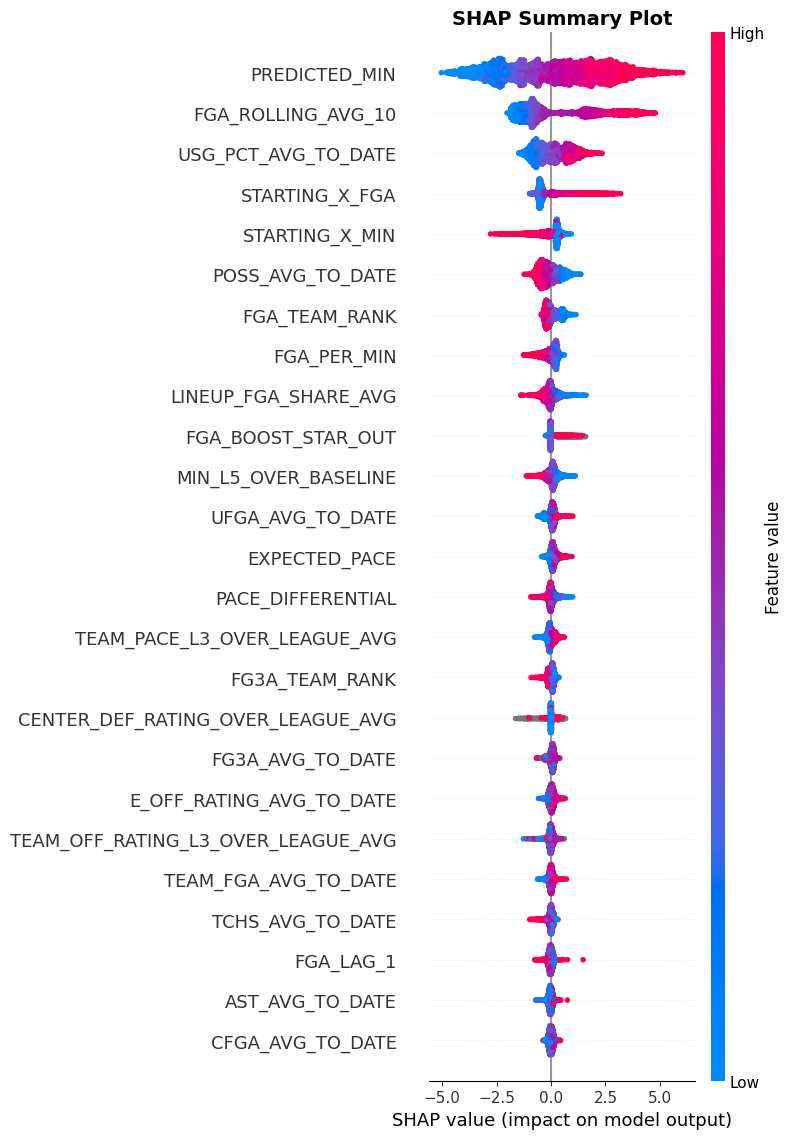

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
analyze_shap(fga_model, val_df_with_preds, fga_features, 'FGA')

Top 25 Features by SHAP importance:
  PREDICTED_FGA                  1.2523
  FG3A_ROLLING_AVG_10            0.8360
  FG3A_PCT_OF_FGA                0.6434
  PREDICTED_MIN                  0.4089
  TEAM_FG3A_ROLLING_AVG_5        0.3200
  FG3A_PER_MIN                   0.2632
  USG_PCT_ROLLING_AVG_5          0.2411
  FG3M_AVG_TO_DATE               0.2336
  FG3A_DELTA_TOPFG3A_RANK_OUT    0.2032
  TEAM_FG3A_AVG_TO_DATE          0.1448
  FG3A_DELTA_STAR_OUT            0.1205
  DIST_AVG_TO_DATE               0.1196
  FG3M_ROLLING_AVG_5             0.0837
  FG_PCT_AVG_TO_DATE             0.0773
  FGA_ROLLING_AVG_5              0.0750
  TEAM_PACE_L5_OVER_LEAGUE_AVG   0.0727
  FGA_L5_OVER_BASELINE           0.0680
  EXPECTED_PACE                  0.0658
  TCHS_AVG_TO_DATE               0.0611
  CENTER_DEF_RATING_OVER_LEAGUE_AVG 0.0586
  FGA_DELTA_TOPFGA_RANK_OUT      0.0568
  FG3A_LAG_1                     0.0543
  STARTING_X_FG3A                0.0527
  OPP_DEF_RATING_OVER_LEAGUE_AVG 0.0516
 

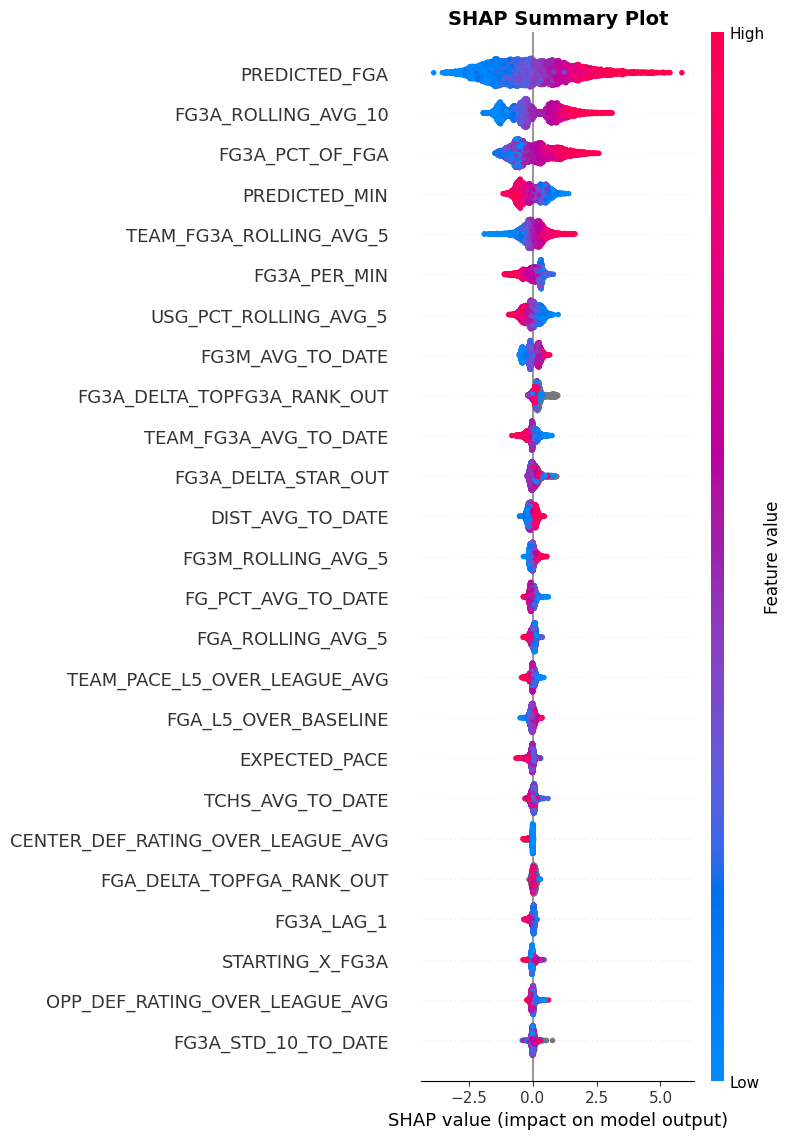

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
analyze_shap(fg3a_model, val_df_with_preds, fg3a_features, 'FG3A')

Top 25 Features by SHAP importance:
  PREDICTED_FGA                  0.6615
  TEAM_FTA_ROLLING_AVG_5         0.5063
  FTA_ROLLING_AVG_10             0.3874
  FTA_TEAM_RANK                  0.2843
  FTA_PER_FGA                    0.1505
  FTA_BOOST_STAR_OUT             0.1491
  FTA_DELTA_STAR_OUT             0.1229
  FTA_DELTA_TOPFTA_RANK_OUT      0.1095
  PREDICTED_MIN                  0.0805
  PREDICTED_FG3A                 0.0776
  PLAYER_AWAY_AVG_FTA_TO_DATE    0.0755
  PLAYER_HOME_AVG_FTA_TO_DATE    0.0714
  TEAM_FTA_AVG_TO_DATE           0.0676
  CENTER_DEF_RATING_OVER_LEAGUE_AVG 0.0547
  FGA_DELTA_TOPFGA_RANK_OUT      0.0540
  POSS_AVG_TO_DATE               0.0535
  FG_PCT_AVG_TO_DATE             0.0481
  AST_AVG_TO_DATE                0.0464
  FTA_STD_10_TO_DATE             0.0450
  FTA_EXPECTATION_LOCATION       0.0435
  PF_AVG_TO_DATE                 0.0417
  PTS_AVG_TO_DATE                0.0412
  LINEUP_FGA_SHARE_AVG           0.0409
  STARTING                       0.0367
 

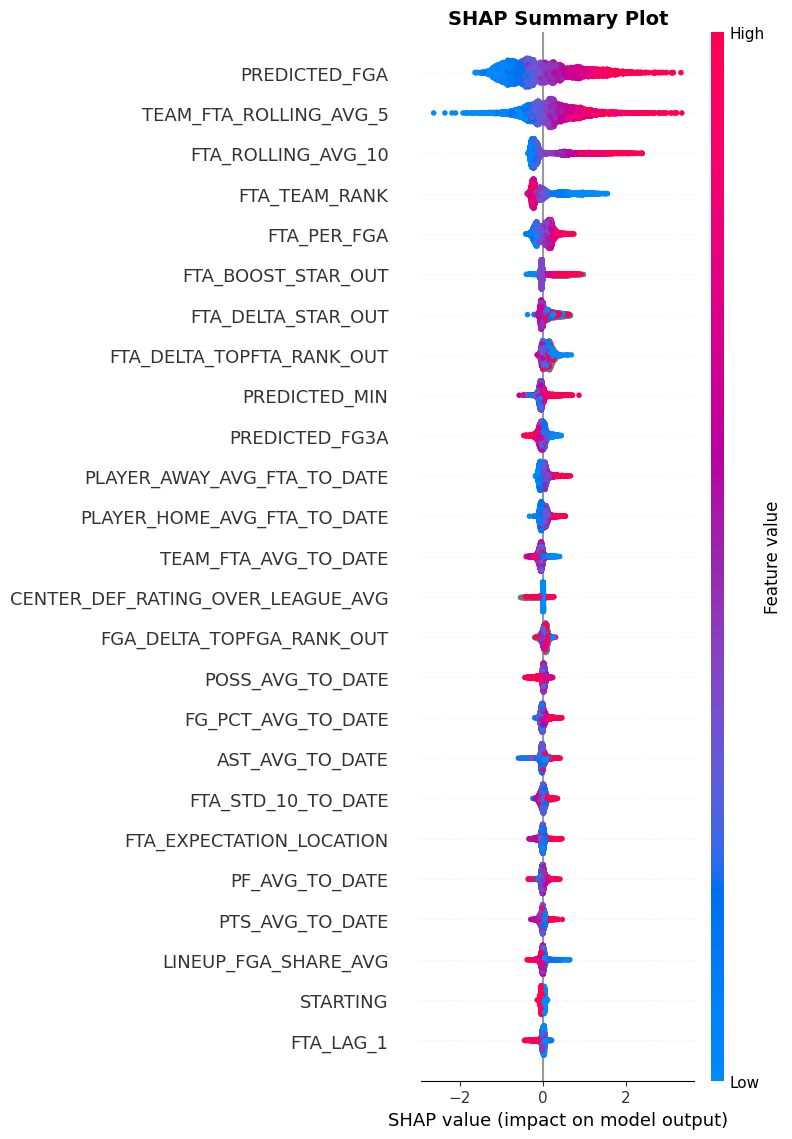

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
analyze_shap(fta_model, val_df_with_preds, fta_features, 'FTA')

In [18]:
PTS_features = [
    'PREDICTED_MIN',
    'PREDICTED_FGA', 
    'PREDICTED_FG3A',  # New cascading output
    'PREDICTED_FTA',  
    'PREDICTED_MIN_x_PREDICTED_FGA',  # Updated interaction
    'PTS_PER_MIN',
    'PTS_L5_OVER_BASELINE_x_PREDICTED_MIN',
    'EXPECTED_PACE_x_PREDICTED_FGA',
    'EXPECTED_PACE_x_PREDICTED_FTA',  # Changed from EXPECTED_PACE_x_PREDICTED_TS_PCT
    'PREDICTED_FGA_x_PREDICTED_FTA',  # Changed from PREDICTED_FGA_x_PREDICTED_TS_PCT
    'PREDICTED_FG3A_x_FG3_PCT_AVG_TO_DATE',  # New interaction
    'STARTING_X_PTS',
    'GAMES_PLAYED_TO_DATE',
    'PTS_CEILING_L5_DELTA',
    'PTS_TEAM_RANK',
    'PTS_AVG_TO_DATE',
    'PTS_ROLLING_AVG_3',
    # 'PTS_ROLLING_AVG_5',
    # 'PTS_ROLLING_AVG_10',
    'PTS_STD_5_TO_DATE',
    'PTS_BOOST_STAR_OUT',
    'CFGA_AVG_TO_DATE',
    'UFGA_AVG_TO_DATE',
    'UFGA_L5_OVER_BASELINE',
    'FTA_AVG_TO_DATE',
    'FTA_L5_OVER_BASELINE',
    'FTA_BOOST_STAR_OUT',
    'FTA_EXPECTATION_LOCATION',
    'FG3A_AVG_TO_DATE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_BOOST_STAR_OUT',
    'PLUS_MINUS_AVG_TO_DATE',
    'PLUS_MINUS_BOOST_STAR_OUT',
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_L5_OVER_BASELINE',
    'FG3_PCT_AVG_TO_DATE',
    'FT_PCT_AVG_TO_DATE',
    'FT_PCT_BOOST_STAR_OUT',
    'TS_PCT_AVG_TO_DATE',  # Keep historical for comparison/context
    'TS_PCT_BOOST_STAR_OUT',
    'PTS_VARIANCE_STABILITY',
    'FGA_VARIANCE_STABILITY',
    'FTA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    'TS_PCT_VARIANCE_STABILITY',
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG'
]
# PTS_features = remove_highly_correlated_features(val_df, PTS_features, target_col='PTS', threshold=0.95)
print(f"len(PTS_features): {len(PTS_features)}")
PTS_features


len(PTS_features): 47


['PREDICTED_MIN',
 'PREDICTED_FGA',
 'PREDICTED_FG3A',
 'PREDICTED_FTA',
 'PREDICTED_MIN_x_PREDICTED_FGA',
 'PTS_PER_MIN',
 'PTS_L5_OVER_BASELINE_x_PREDICTED_MIN',
 'EXPECTED_PACE_x_PREDICTED_FGA',
 'EXPECTED_PACE_x_PREDICTED_FTA',
 'PREDICTED_FGA_x_PREDICTED_FTA',
 'PREDICTED_FG3A_x_FG3_PCT_AVG_TO_DATE',
 'STARTING_X_PTS',
 'GAMES_PLAYED_TO_DATE',
 'PTS_CEILING_L5_DELTA',
 'PTS_TEAM_RANK',
 'PTS_AVG_TO_DATE',
 'PTS_ROLLING_AVG_3',
 'PTS_STD_5_TO_DATE',
 'PTS_BOOST_STAR_OUT',
 'CFGA_AVG_TO_DATE',
 'UFGA_AVG_TO_DATE',
 'UFGA_L5_OVER_BASELINE',
 'FTA_AVG_TO_DATE',
 'FTA_L5_OVER_BASELINE',
 'FTA_BOOST_STAR_OUT',
 'FTA_EXPECTATION_LOCATION',
 'FG3A_AVG_TO_DATE',
 'FG3A_L5_OVER_BASELINE',
 'FG3A_BOOST_STAR_OUT',
 'PLUS_MINUS_AVG_TO_DATE',
 'PLUS_MINUS_BOOST_STAR_OUT',
 'FG_PCT_AVG_TO_DATE',
 'FG_PCT_L5_OVER_BASELINE',
 'FG3_PCT_AVG_TO_DATE',
 'FT_PCT_AVG_TO_DATE',
 'FT_PCT_BOOST_STAR_OUT',
 'TS_PCT_AVG_TO_DATE',
 'TS_PCT_BOOST_STAR_OUT',
 'PTS_VARIANCE_STABILITY',
 'FGA_VARIANCE_STABILITY',

In [140]:
# Interaction terms for points model (using new cascading structure: MIN → FGA → FG3A → FTA)
# Order matches PTS_features list for clarity

# PREDICTED_MIN_x_PREDICTED_FGA (feature #5 in PTS_features)
train_df_with_preds['PREDICTED_MIN_x_PREDICTED_FGA'] = (
    train_df_with_preds['PREDICTED_MIN'] * train_df_with_preds['PREDICTED_FGA']
)
val_df_with_preds['PREDICTED_MIN_x_PREDICTED_FGA'] = (
    val_df_with_preds['PREDICTED_MIN'] * val_df_with_preds['PREDICTED_FGA']
)

# PTS_PER_MIN (feature #6 in PTS_features)
train_df_with_preds['PTS_PER_MIN'] = (
    train_df_with_preds['PTS_AVG_TO_DATE'] / (train_df_with_preds['PREDICTED_MIN'] + 1e-8)
)
val_df_with_preds['PTS_PER_MIN'] = (
    val_df_with_preds['PTS_AVG_TO_DATE'] / (val_df_with_preds['PREDICTED_MIN'] + 1e-8)
)

# PTS_L5_OVER_BASELINE_x_PREDICTED_MIN (feature #7 in PTS_features)
train_df_with_preds['PTS_L5_OVER_BASELINE_x_PREDICTED_MIN'] = (
    train_df_with_preds['PTS_L5_OVER_BASELINE'] * train_df_with_preds['PREDICTED_MIN']
)
val_df_with_preds['PTS_L5_OVER_BASELINE_x_PREDICTED_MIN'] = (
    val_df_with_preds['PTS_L5_OVER_BASELINE'] * val_df_with_preds['PREDICTED_MIN']
)

# EXPECTED_PACE_x_PREDICTED_FGA (feature #8 in PTS_features)
train_df_with_preds['EXPECTED_PACE_x_PREDICTED_FGA'] = (
    train_df_with_preds['EXPECTED_PACE'] * train_df_with_preds['PREDICTED_FGA']
)
val_df_with_preds['EXPECTED_PACE_x_PREDICTED_FGA'] = (
    val_df_with_preds['EXPECTED_PACE'] * val_df_with_preds['PREDICTED_FGA']
)

# EXPECTED_PACE_x_PREDICTED_FTA (feature #9 in PTS_features)
train_df_with_preds['EXPECTED_PACE_x_PREDICTED_FTA'] = (
    train_df_with_preds['EXPECTED_PACE'] * train_df_with_preds['PREDICTED_FTA']
)
val_df_with_preds['EXPECTED_PACE_x_PREDICTED_FTA'] = (
    val_df_with_preds['EXPECTED_PACE'] * val_df_with_preds['PREDICTED_FTA']
)

# PREDICTED_FGA_x_PREDICTED_FTA (feature #10 in PTS_features)
train_df_with_preds['PREDICTED_FGA_x_PREDICTED_FTA'] = (
    train_df_with_preds['PREDICTED_FGA'] * train_df_with_preds['PREDICTED_FTA']
)
val_df_with_preds['PREDICTED_FGA_x_PREDICTED_FTA'] = (
    val_df_with_preds['PREDICTED_FGA'] * val_df_with_preds['PREDICTED_FTA']
)

# PREDICTED_FG3A_x_FG3_PCT_AVG_TO_DATE (feature #11 in PTS_features)
train_df_with_preds['PREDICTED_FG3A_x_FG3_PCT_AVG_TO_DATE'] = (
    train_df_with_preds['PREDICTED_FG3A'] * train_df_with_preds['FG3_PCT_AVG_TO_DATE']
)
val_df_with_preds['PREDICTED_FG3A_x_FG3_PCT_AVG_TO_DATE'] = (
    val_df_with_preds['PREDICTED_FG3A'] * val_df_with_preds['FG3_PCT_AVG_TO_DATE']
)

# Additional interaction term (calculated but not in PTS_features - kept for potential future use)
train_df_with_preds['EXPECTED_PACE_x_PREDICTED_MIN'] = (
    train_df_with_preds['EXPECTED_PACE'] * train_df_with_preds['PREDICTED_MIN']
)
val_df_with_preds['EXPECTED_PACE_x_PREDICTED_MIN'] = (
    val_df_with_preds['EXPECTED_PACE'] * val_df_with_preds['PREDICTED_MIN']
)

train_df_pts = train_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()
val_df_pts = val_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()

print(f"\nPreparing feature matrices...")
print(f"Training samples: {len(train_df_pts)}")
print(f"Validation samples: {len(val_df_pts)}")
print(f"Features: {len(PTS_features)}")
print(f"Points range: {train_df_pts['PTS'].min()} - {train_df_pts['PTS'].max()}")
print(f"Mean points: {train_df_pts['PTS'].mean():.2f}")


Preparing feature matrices...
Training samples: 44087
Validation samples: 5870
Features: 49
Points range: 0 - 60
Mean points: 12.18


In [141]:
pts_model = train_ngboost_model(train_df_pts, val_df_pts, PTS_features, 'PTS', n_estimators=500)

Using passed validation data to check for early stopping.


In [51]:
y_pred = predict_mean(pts_model, val_df_pts, PTS_features, variance_calibration={'low': 1.15, 'medium': 0.85, 'high': 0.95}, return_type='Median')
y_actual = val_df_pts['PTS'].values

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"PTS Model Metrics: MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")
print(f"Predicted: {y_pred.mean():.2f} ± {y_pred.std():.2f} | Actual: {y_actual.mean():.2f} ± {y_actual.std():.2f}")

PTS Model Metrics: MAE=3.512 | RMSE=4.540 | R²=0.736
Predicted: 12.36 ± 7.14 | Actual: 12.50 ± 8.83


In [142]:
analyze_ngboost_shap(pts_model, val_df_pts, PTS_features, sample_size=1000)

SHAP Analysis - Main Model:


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/shap/explainers/_tree.py:1404: UserWarning: Translating model_output="raw" to model_output=0 for the 0-th parameter in the distribution. Use model_output=0 directly to avoid this warning.
  warnings.warn(


Top 20 Features:
  PREDICTED_FGA_x_PREDICTED_FTA              0.1936
  PREDICTED_FGA                              0.1698
  EXPECTED_PACE_x_PREDICTED_FGA              0.1513
  PREDICTED_FG3A                             0.1444
  FG3A_AVG_TO_DATE                           0.0703
  FG_PCT_AVG_TO_DATE                         0.0309
  PTS_TEAM_RANK                              0.0275
  FORWARD_DEF_RATING_OVER_LEAGUE_AVG         0.0249
  GUARD_DEF_RATING_OVER_LEAGUE_AVG           0.0238
  PREDICTED_MIN                              0.0189
Bottom 10 Features:
  PTS_ROLLING_AVG_5                          0.0008
  TS_PCT_BOOST_STAR_OUT                      0.0008
  PTS_STD_5_TO_DATE                          0.0008
  PTS_CEILING_L5_DELTA                       0.0007
  PTS_BOOST_STAR_OUT                         0.0007
  PTS_AVG_TO_DATE                            0.0006
  FT_PCT_BOOST_STAR_OUT                      0.0006
  FTA_L5_OVER_BASELINE                       0.0005
  FTA_VARIANCE_STABILITY   

(                                 feature  importance
 9          PREDICTED_FGA_x_PREDICTED_FTA    0.193579
 1                          PREDICTED_FGA    0.169818
 7          EXPECTED_PACE_x_PREDICTED_FGA    0.151315
 2                         PREDICTED_FG3A    0.144413
 28                      FG3A_AVG_TO_DATE    0.070314
 33                    FG_PCT_AVG_TO_DATE    0.030938
 14                         PTS_TEAM_RANK    0.027458
 48    FORWARD_DEF_RATING_OVER_LEAGUE_AVG    0.024851
 47      GUARD_DEF_RATING_OVER_LEAGUE_AVG    0.023753
 0                          PREDICTED_MIN    0.018908
 21                      CFGA_AVG_TO_DATE    0.018788
 3                          PREDICTED_FTA    0.010874
 43               FG3A_VARIANCE_STABILITY    0.008735
 29                 FG3A_L5_OVER_BASELINE    0.008033
 24                       FTA_AVG_TO_DATE    0.007791
 8          EXPECTED_PACE_x_PREDICTED_FTA    0.006603
 27              FTA_EXPECTATION_LOCATION    0.006442
 12                  GAMES_P

In [147]:
mean_log, scale_log, var_log = get_distribution_params(
    pts_model, val_df_pts, PTS_features,
    variance_calibration={'low': 1.15, 'medium': 0.95, 'high': 0.98}  # ← Adjusted
)

# Use MEDIAN for point prediction (not mean)
predictions = np.expm1(mean_log)  # ← Changed: this is the median

# Sample (same as before)
samples_log = np.random.normal(
    mean_log[:, np.newaxis], 
    scale_log[:, np.newaxis], 
    size=(len(mean_log), 10000)
)
samples = np.expm1(samples_log)
percentiles = np.percentile(samples, [5, 25, 50, 75, 95], axis=1)

In [148]:
# Check calibration quality
actuals = val_df_pts['PTS'].values

in_90 = ((actuals >= percentiles[0]) & (actuals <= percentiles[4])).mean()
in_50 = ((actuals >= percentiles[1]) & (actuals <= percentiles[3])).mean()
below_median = (actuals < percentiles[2]).mean()

print("\nCalibration Quality:")
print(f"  90% interval coverage: {in_90:.1%} (target: 90%)")
print(f"  50% interval coverage: {in_50:.1%} (target: 50%)")
print(f"  Below median: {below_median:.1%} (target: 50%)")

# By bin
for bin_name, (low, high) in [('Low', (0, 7)), ('Med', (7, 15)), ('High', (15, 100))]:
    mask = (predictions >= low) & (predictions < high)
    if mask.sum() > 0:
        bin_actuals = actuals[mask]
        bin_in_90 = ((bin_actuals >= percentiles[0][mask]) & 
                     (bin_actuals <= percentiles[4][mask])).mean()
        print(f"  {bin_name}: {bin_in_90:.1%} in 90% interval")


Calibration Quality:
  90% interval coverage: 90.4% (target: 90%)
  50% interval coverage: 51.1% (target: 50%)
  Below median: 42.6% (target: 50%)
  Low: 90.0% in 90% interval
  Med: 90.7% in 90% interval
  High: 90.3% in 90% interval


In [149]:
# Detailed diagnostic
actuals = val_df_pts['PTS'].values

print("\n" + "="*60)
print("DETAILED DIAGNOSTIC")
print("="*60)

# 1. Check if predictions == percentiles[2]
print(f"\nPredictions vs Percentiles[2] (median):")
print(f"  predictions mean: {predictions.mean():.2f}")
print(f"  percentiles[2] mean: {percentiles[2].mean():.2f}")
print(f"  Difference: {(predictions - percentiles[2]).mean():.4f}")
print(f"  Max diff: {np.abs(predictions - percentiles[2]).max():.4f}")

# 2. Check actual distribution
print(f"\nActual vs Predicted distribution:")
print(f"  Actual mean: {actuals.mean():.2f}")
print(f"  Actual median: {np.median(actuals):.2f}")
print(f"  Predicted median: {predictions.mean():.2f}")

# 3. Check by bin
print(f"\nBelow median by bin:")
bins = [(0, 7), (7, 15), (15, 100)]
for name, (low, high) in [('Low', bins[0]), ('Med', bins[1]), ('High', bins[2])]:
    mask = (predictions >= low) & (predictions < high)
    if mask.sum() > 0:
        bin_below = (actuals[mask] < predictions[mask]).mean()
        bin_actuals_mean = actuals[mask].mean()
        bin_preds_mean = predictions[mask].mean()
        print(f"  {name}: {bin_below:.1%} below median (actual: {bin_actuals_mean:.1f}, pred: {bin_preds_mean:.1f})")

# 4. Look at residuals
residuals = predictions - actuals
print(f"\nResiduals (pred - actual):")
print(f"  Mean: {residuals.mean():.2f}")
print(f"  Median: {np.median(residuals):.2f}")
print(f"  This tells us predictions are systematically {'high' if residuals.mean() > 0 else 'low'}")


DETAILED DIAGNOSTIC

Predictions vs Percentiles[2] (median):
  predictions mean: 11.38
  percentiles[2] mean: 11.38
  Difference: 0.0016
  Max diff: 0.2897

Actual vs Predicted distribution:
  Actual mean: 12.52
  Actual median: 11.00
  Predicted median: 11.38

Below median by bin:
  Low: 44.0% below median (actual: 5.2, pred: 4.4)
  Med: 42.2% below median (actual: 11.8, pred: 10.7)
  High: 41.6% below median (actual: 22.6, pred: 21.1)

Residuals (pred - actual):
  Mean: -1.14
  Median: -0.80
  This tells us predictions are systematically low


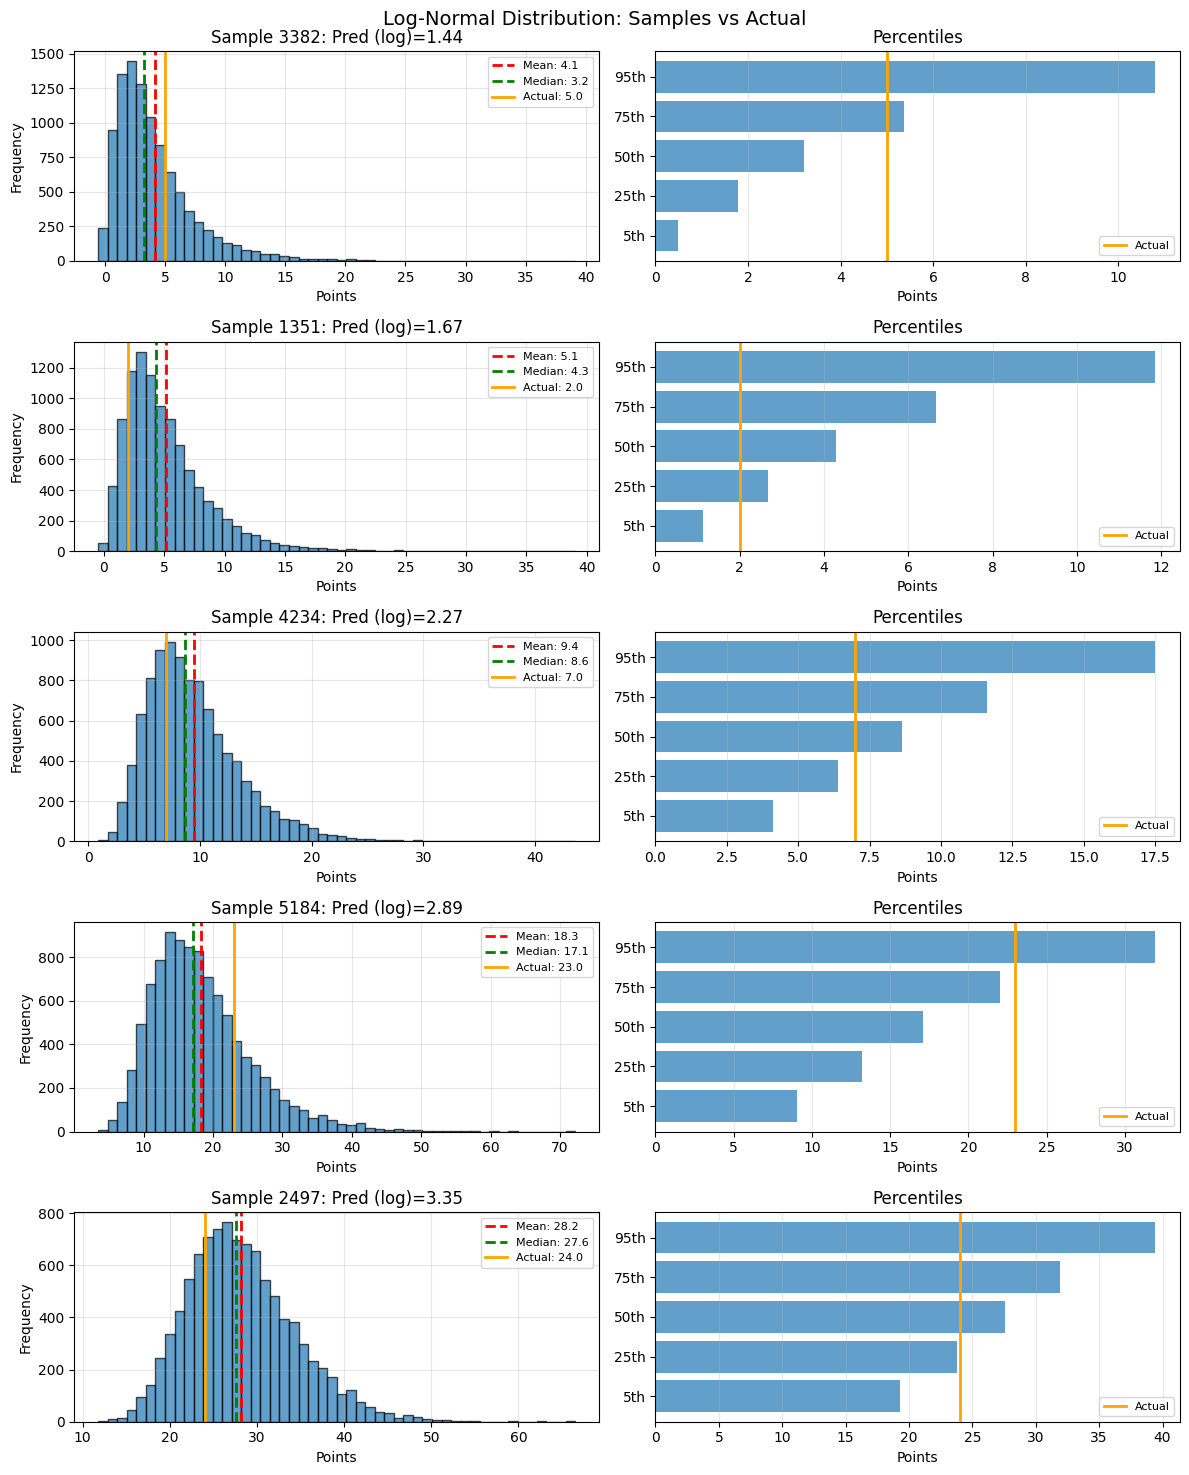

Distribution Summary
Mean Variance (log space): 0.2263
Mean Std Dev (log space): 0.4472

Sample Statistics:
  Mean of predictions: 11.38
  Std of predictions: 7.18
  Actual mean: 12.52
  Actual std: 8.83

Percentile Ranges (across all predictions):
  5th-95th: 6.0 - 22.1
  25th-75th: 8.7 - 14.9


In [150]:
import matplotlib.pyplot as plt

n_examples = 5
example_indices = np.random.choice(len(mean_log), n_examples, replace=False)

fig, axes = plt.subplots(n_examples, 2, figsize=(12, 3*n_examples))
fig.suptitle('Log-Normal Distribution: Samples vs Actual', fontsize=14)

for idx, ax_row in zip(example_indices, axes):
    ax_row[0].hist(samples[idx], bins=50, alpha=0.7, edgecolor='black')
    ax_row[0].axvline(samples[idx].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {samples[idx].mean():.1f}')
    ax_row[0].axvline(percentiles[2, idx], color='green', linestyle='--', linewidth=2, label=f'Median: {percentiles[2, idx]:.1f}')
    ax_row[0].axvline(val_df_pts.iloc[idx]['PTS'], color='orange', linestyle='-', linewidth=2, label=f'Actual: {val_df_pts.iloc[idx]["PTS"]:.1f}')
    ax_row[0].set_xlabel('Points')
    ax_row[0].set_ylabel('Frequency')
    ax_row[0].set_title(f'Sample {idx}: Pred (log)={mean_log[idx]:.2f}')
    ax_row[0].legend(fontsize=8)
    ax_row[0].grid(alpha=0.3)
    
    percentiles_vals = percentiles[:, idx]
    ax_row[1].barh(['5th', '25th', '50th', '75th', '95th'], percentiles_vals, alpha=0.7)
    ax_row[1].axvline(val_df_pts.iloc[idx]['PTS'], color='orange', linestyle='-', linewidth=2, label='Actual')
    ax_row[1].set_xlabel('Points')
    ax_row[1].set_title('Percentiles')
    ax_row[1].legend(fontsize=8)
    ax_row[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("=" * 60)
print("Distribution Summary")
print("=" * 60)
print(f"Mean Variance (log space): {var_log.mean():.4f}")
print(f"Mean Std Dev (log space): {scale_log.mean():.4f}")
print(f"\nSample Statistics:")
print(f"  Mean of predictions: {predictions.mean():.2f}")
print(f"  Std of predictions: {predictions.std():.2f}")
print(f"  Actual mean: {val_df_pts['PTS'].mean():.2f}")
print(f"  Actual std: {val_df_pts['PTS'].std():.2f}")
print(f"\nPercentile Ranges (across all predictions):")
print(f"  5th-95th: {percentiles[0].mean():.1f} - {percentiles[4].mean():.1f}")
print(f"  25th-75th: {percentiles[1].mean():.1f} - {percentiles[3].mean():.1f}")

In [151]:
# Evaluate performance by calibration bin
median_preds = np.expm1(mean_log)
actuals = val_df_pts['PTS'].values

for bin_name, mask in [
    ('Low (<7)', median_preds < 7),
    ('Medium (7-15)', (median_preds >= 7) & (median_preds < 15)),
    ('High (>=15)', median_preds >= 15),
    ('super high (>=20)', median_preds >= 25)
]:
    pred_bin = predictions[mask]
    actual_bin = actuals[mask]
    bias = pred_bin.mean() - actual_bin.mean()
    mae = np.mean(np.abs(pred_bin - actual_bin))
    
    print(f"\n{bin_name}:")
    print(f"  n = {mask.sum()}")
    print(f"  Predicted: {pred_bin.mean():.2f} ± {pred_bin.std():.2f}")
    print(f"  Actual:    {actual_bin.mean():.2f} ± {actual_bin.std():.2f}")
    print(f"  Bias:      {bias:+.2f} ({'over' if bias > 0 else 'under'}predicting)")
    print(f"  MAE:       {mae:.2f}")


Low (<7):
  n = 1945
  Predicted: 4.38 ± 1.59
  Actual:    5.21 ± 3.78
  Bias:      -0.83 (underpredicting)
  MAE:       2.63

Medium (7-15):
  n = 2352
  Predicted: 10.66 ± 2.26
  Actual:    11.80 ± 5.22
  Bias:      -1.14 (underpredicting)
  MAE:       3.83

High (>=15):
  n = 1573
  Predicted: 21.14 ± 5.00
  Actual:    22.65 ± 7.94
  Bias:      -1.51 (underpredicting)
  MAE:       4.64

super high (>=20):
  n = 325
  Predicted: 29.12 ± 3.37
  Actual:    31.53 ± 7.17
  Bias:      -2.40 (underpredicting)
  MAE:       5.12


In [152]:
import joblib

project_root = Path('/Users/alexgonzalez/Documents/NBA-Prop-Predictor')

os.chdir(project_root)
print(f"Changed to directory: {os.getcwd()}")

save_dir = project_root / 'src' / 'models' / 'saved'
save_dir.mkdir(parents=True, exist_ok=True)

# Save models
joblib.dump(min_model, save_dir / 'min_model.pkl')
joblib.dump(fg3a_model, save_dir / 'fg3a_model.pkl')
joblib.dump(fga_model, save_dir / 'fga_model.pkl')
joblib.dump(fta_model, save_dir / 'fta_model.pkl')
joblib.dump(min_features, save_dir / 'min_features.pkl')
joblib.dump(fg3a_features, save_dir / 'fg3a_features.pkl')
joblib.dump(fga_features, save_dir / 'fga_features.pkl')
joblib.dump(fta_features, save_dir / 'fta_features.pkl')

model_wrapper = {
    'mean_model': pts_model,
    'features': PTS_features,
    'variance_calibration': {'low': 1.08, 'medium': 0.90, 'high': 0.94} ,
    'bins': [(0, 7), (7, 15), (15, 100)]
}

joblib.dump(model_wrapper, save_dir / 'pts_model_wrapper.pkl')

print(f"Models saved to: {save_dir}")
print("Models, features, and calibrations saved successfully!")

Changed to directory: /Users/alexgonzalez/Documents/NBA-Prop-Predictor
Models saved to: /Users/alexgonzalez/Documents/NBA-Prop-Predictor/src/models/saved
Models, features, and calibrations saved successfully!
